## ISSUE 2: 

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import get_HEP_data as gHd

### Task 1 (n_hits vs eta)
$$
\eta = -\ln \left[ \tan \left(\frac{\theta}{2}\right) \right] =\frac{1}{2} \ln \left[ \frac{|\vec{p}| + p_z}{|\vec{p}| - p_z} \right]
$$

/var/folders/vw/5snrydv96d34jy4vgx0h68t80000gn/T/ipykernel_11714/2574241736.py:29: RuntimeWarning: invalid value encountered in divide
  H_norm = H / H.sum(axis=1, keepdims=True)


Text(-1, 7.5, '9 hits')

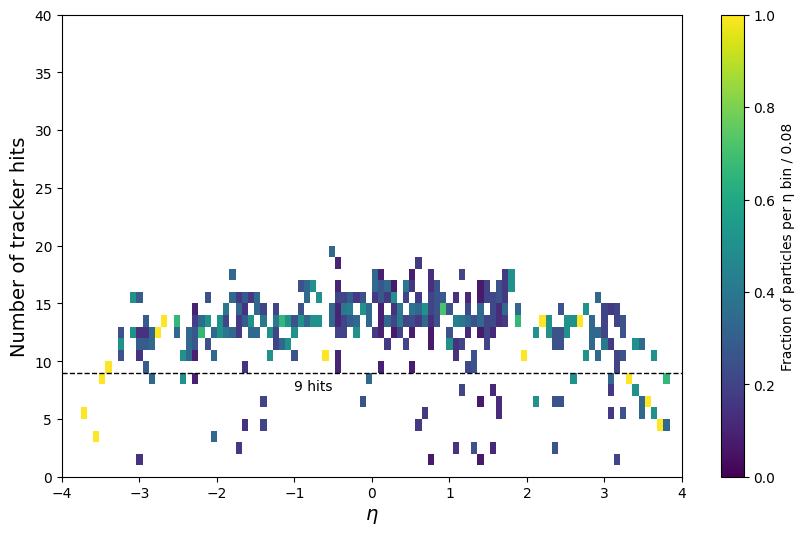

In [19]:
particles = gHd.get_particles()

particles = particles[abs(particles['vx']) < 1]
particles = particles[abs(particles['vy']) < 1]
particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
particles = particles[particles['pT'] > 1]

particles = particles[particles['charge'] != 0]

particles['p'] = np.sqrt(particles['px']**2 + particles['py']**2 + particles['pz']**2)

particles['eta'] = 1/2 * np.log(
    (particles['p'] + particles['pz'])/
    (particles['p'] - particles['pz'])
)

particles = particles[particles['num_tracker_hits'] > 0]

eta_bins = np.linspace(-4, 4, 101)
hits_bins = np.arange(0, 41, 1)

# Compute 2D histogram 
H, xedges, yedges = np.histogram2d(
    particles['eta'], 
    particles['num_tracker_hits'], 
    bins=(eta_bins, hits_bins)
)

H_norm = H / H.sum(axis=1, keepdims=True)
H_norm = np.nan_to_num(H_norm)  # replace NaNs from empty bins with 0

H_masked = np.ma.masked_where(H_norm == 0, H_norm) 

cmap = plt.cm.viridis.copy()
cmap.set_bad(color='white')

fig, ax = plt.subplots(figsize=(10, 6))
pcm = ax.pcolormesh(
    xedges, yedges, H_masked.T,
    cmap=cmap,
    vmin=0, vmax=np.max(H_norm)  # linear color scale
)

# Colorbar
cbar = plt.colorbar(pcm, ax=ax)
cbar.set_label('Fraction of particles per η bin / {:.2f}'.format(xedges[1]-xedges[0]))

# Axis labels and style
ax.set_xlabel(r'$\eta$', fontsize=14)
ax.set_ylabel('Number of tracker hits', fontsize=14)
ax.set_xlim(-4, 4)
ax.set_ylim(0, 40)

# Dashed reference line at 9 hits 
ax.axhline(9, color='k', linestyle='--', linewidth=1)
ax.text(-1, 7.5, '9 hits', fontsize=10, color='k')


### Task 2 (Calo Hits Distribution)

(0.0, 1600.0)

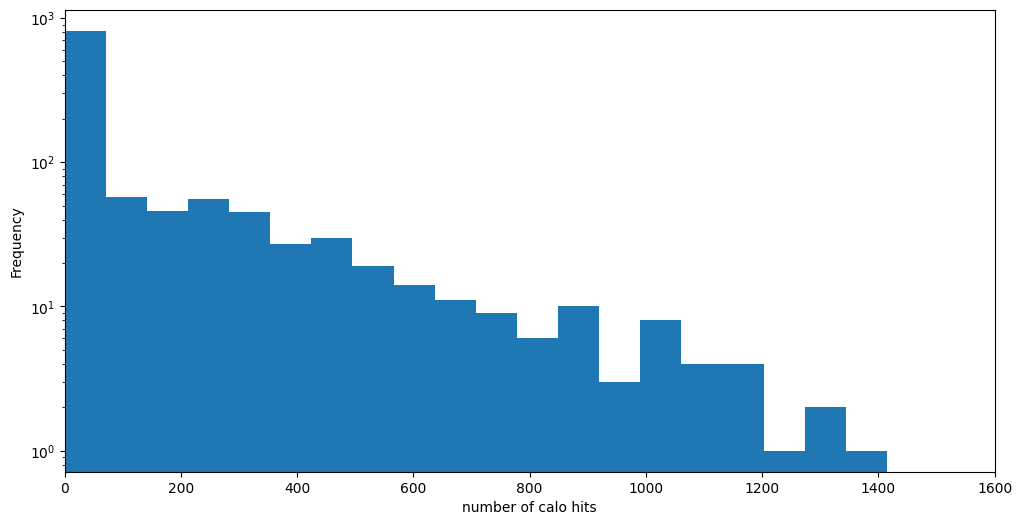

In [20]:
fig, ax = plt.subplots(figsize=(12,6))

particles = gHd.get_particles()
particles = particles[abs(particles['vx']) < 1]
particles = particles[abs(particles['vy']) < 1]
particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
particles = particles[particles['pT'] > 1]

particles = particles[particles['num_calo_hits'] < 1500]

ax.hist(particles['num_calo_hits'], bins=20)

ax.set_yscale('log')

ax.set_ylabel('Frequency')

ax.set_xlabel('number of calo hits')

ax.set_xlim(0,1600)

### Task 3 (Looking at kinks in tracks)

This code downloads the data in all three dimensions so that it can be viewed in this link:
https://finnbarwilson.github.io/Project_HEP/Code/Interactive3Dviewer.html

In [21]:
import json

all_events_data = {}

for n in range(10):
    # retreaving data:
    particles = gHd.get_particles()
    tracker_hits = gHd.get_tracker_hits()
    particles = particles[particles['event_id'] == n].copy()
    tracker_hits = tracker_hits[tracker_hits['event_id'] == n].copy()

    # Setting conditions
    particles = particles[abs(particles['vx']) < 1]
    particles = particles[abs(particles['vy']) < 1]
    particles['pT'] = np.sqrt(particles['px']**2 + particles['py']**2)
    particles = particles[particles['pT'] > 0.5]

    # Getting tracker hits that match the particles
    particles_id = particles["particle_id"].unique()
    tracker_hits = tracker_hits[tracker_hits["particle_id"].isin(particles_id)]
        
    # Finding the radius from the center of detector:
    # Note: Using x,y,z from the *origin* (0,0,0).
    tracker_hits['r'] = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2 + tracker_hits['z']**2)
    # Ordering data with respect to the radius so that straight lines are plotted
    tracker_hits = tracker_hits.sort_values(by=['particle_id', 'r'])

    event_tracks = []
    # Group by particle_id to create individual tracks
    for particle_id, group_of_hits in tracker_hits.groupby('particle_id'):
        # Get the points as a list of dictionaries: [{'x':_,'y':_,'z':_}, ...]
        points = group_of_hits[['x', 'y', 'z']].to_dict(orient='records')
        
        # We need at least 2 points to draw a line
        if len(points) > 1:
            event_tracks.append({
                'particle_id': int(particle_id),
                'points': points
            })
    
    all_events_data[n] = event_tracks
    print(f"Event {n}: Processed {len(event_tracks)} tracks.")

'''# Save all processed event data to a JSON file
output_filename = 'data/tracks_data.json'
with open(output_filename, 'w') as f:
    json.dump(all_events_data, f, indent=4)'''

Event 0: Processed 30 tracks.
Event 1: Processed 37 tracks.
Event 2: Processed 42 tracks.
Event 3: Processed 55 tracks.
Event 4: Processed 36 tracks.
Event 5: Processed 84 tracks.
Event 6: Processed 83 tracks.
Event 7: Processed 66 tracks.
Event 8: Processed 73 tracks.
Event 9: Processed 96 tracks.


"# Save all processed event data to a JSON file\noutput_filename = 'data/tracks_data.json'\nwith open(output_filename, 'w') as f:\n    json.dump(all_events_data, f, indent=4)"

### Task 4 (make plots of track hit residuals: true - measured value in x, y, z - split into strip, pixel, barrel, end-cap)

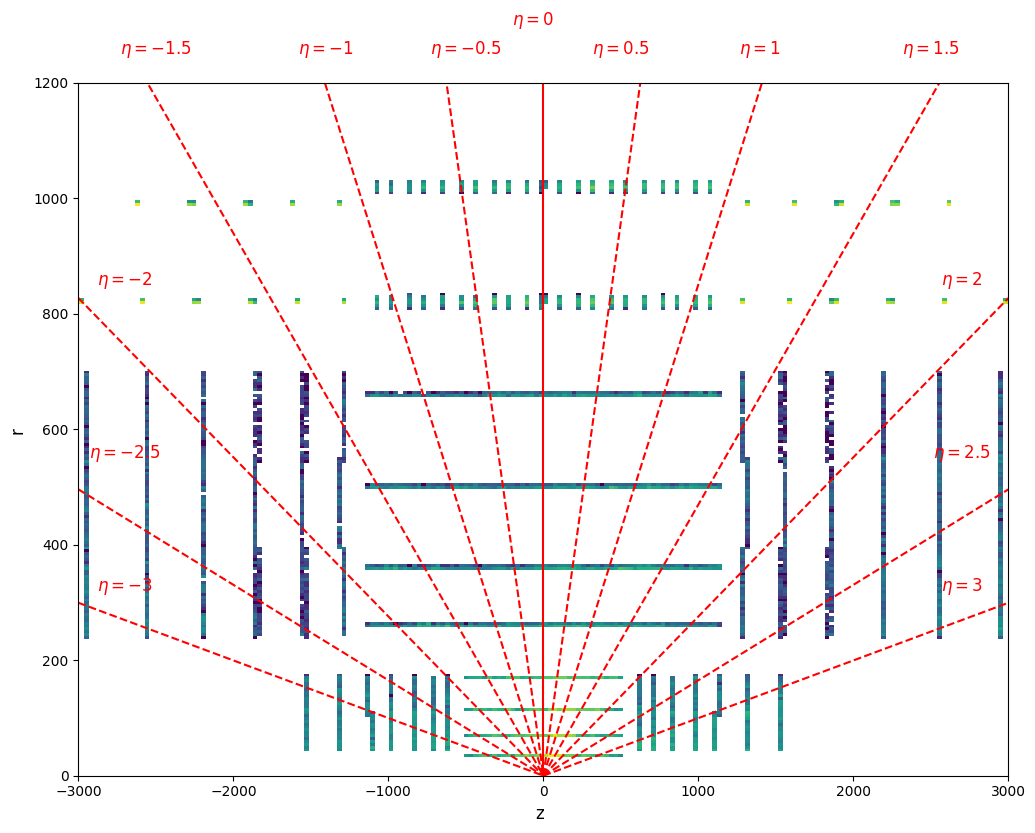

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

tracker_hits = gHd.get_tracker_hits()

r = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2)
z = tracker_hits['z']

plt.figure(figsize=(12, 9))
plt.hist2d(z, r, bins=200, norm=colors.LogNorm())

plt.xlabel('z ', fontsize=12)
plt.ylabel('r ', fontsize=12)

z_max = 3000
r_max = 1200 
plt.xlim(-z_max, z_max)
plt.ylim(0, r_max)

eta_values = [0, 0.5, 1, 1.5, 2, 2.5, 3]
z_range_positive = np.array([0, z_max])
z_range_negative = np.array([-z_max, 0])

for eta_val in eta_values:
    if eta_val == 0:
        # eta = 0 corresponds to theta = pi/2, which is the line z = 0
        plt.axvline(x = 0,ymin = 0, ymax = 1200, c = 'r', label='$\eta=0$' )
        plt.text(-200, 1300, '$\eta = 0$', color='red', ha='left', fontsize=12)
    else:
        # Calculate theta from eta: theta = 2 * arctan(exp(-eta))
        theta = 2 * np.arctan(np.exp(-eta_val))
        
        # Calculate the slope: r/z = tan(theta)
        slope = np.tan(theta)
        
        # Calculate r values for positive and negative z
        r_vals_positive = slope * z_range_positive
        r_vals_negative = slope * np.abs(z_range_negative) # r is always positive
        
        # Plot the lines
        plt.plot(z_range_positive, r_vals_positive, 'r--')
        plt.plot(z_range_negative, r_vals_negative, 'r--')
        
        # Add text labels for eta
        label_y = {"0.5":1250,"1":1250,"1.5":1250,"2":850,"2.5":550,"3":320}
        label_x = {"0.5":500,"1":1400,"1.5":2500,"2":2700,"2.5":2700,"3":2700}
        # Positive eta side
        plt.text(label_x[f"{eta_val}"], label_y[f"{eta_val}"], f'$\eta = {eta_val}$', 
                 color='red', ha='center', fontsize=12)
        # Negative eta side
        plt.text(-label_x[f"{eta_val}"], label_y[f"{eta_val}"], f'$\eta = -{eta_val}$', 
                 color='red', ha='center', fontsize=12)

<Figure size 1200x900 with 0 Axes>

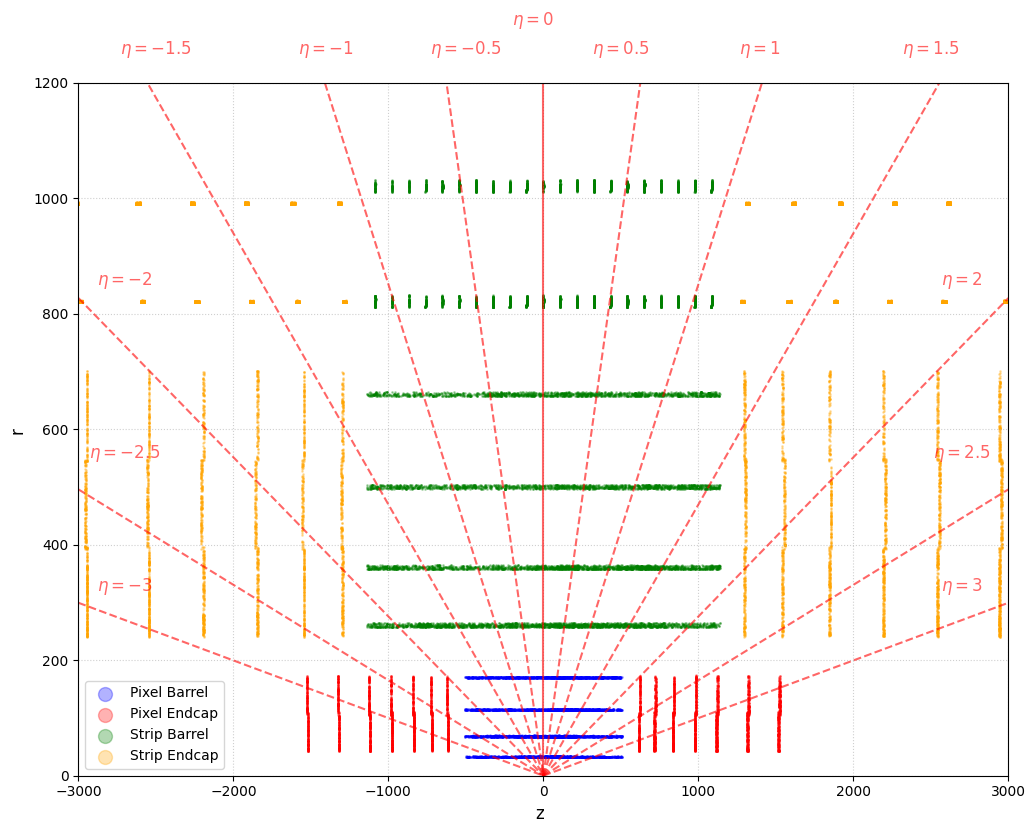

In [23]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import numpy as np

tracker_hits = gHd.get_tracker_hits()

tracker_hits['r'] = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2)

plt.figure(figsize=(12, 9))

PIXEL_VOLUMES = [16, 17, 18]
STRIP_VOLUMES = [23, 24, 25, 28, 29, 30]
ENDCAP_VOLUMES = [16, 18, 23, 25, 28, 30]
BARREL_VOLUMES = [17, 24, 29]

is_endcap = tracker_hits['volume_id'].isin(ENDCAP_VOLUMES)
is_barrel = tracker_hits['volume_id'].isin(BARREL_VOLUMES)

is_pixel = tracker_hits['volume_id'].isin(PIXEL_VOLUMES)
is_strip = tracker_hits['volume_id'].isin(STRIP_VOLUMES)

df_pixel_barrel = tracker_hits[is_pixel & is_barrel]
df_pixel_endcap = tracker_hits[is_pixel & is_endcap]
df_strip_barrel = tracker_hits[is_strip & is_barrel]
df_strip_endcap = tracker_hits[is_strip & is_endcap]


plt.figure(figsize=(12, 9))

plt.scatter(df_pixel_barrel['z'], df_pixel_barrel['r'], 
            label='Pixel Barrel', c='blue', s=1, alpha=0.3)
plt.scatter(df_pixel_endcap['z'], df_pixel_endcap['r'], 
            label='Pixel Endcap', c='red', s=1, alpha=0.3)
plt.scatter(df_strip_barrel['z'], df_strip_barrel['r'], 
            label='Strip Barrel', c='green', s=1, alpha=0.3)
plt.scatter(df_strip_endcap['z'], df_strip_endcap['r'], 
            label='Strip Endcap', c='orange', s=1, alpha=0.3)


plt.legend(markerscale=10) 
plt.grid(True, linestyle=':', alpha=0.6)

plt.xlabel('z ', fontsize=12)
plt.ylabel('r ', fontsize=12)

z_max = 3000
r_max = 1200 
plt.xlim(-z_max, z_max)
plt.ylim(0, r_max)

eta_values = [0, 0.5, 1, 1.5, 2, 2.5, 3]
z_range_positive = np.array([0, z_max])
z_range_negative = np.array([-z_max, 0])

for eta_val in eta_values:
    if eta_val == 0:
        # eta = 0 corresponds to theta = pi/2, which is the line z = 0
        plt.axvline(x = 0, c = 'r', label='$\eta=0$', alpha=0.6 )
        plt.text(-200, 1300, '$\eta = 0$', color='red', ha='left', fontsize=12, alpha=0.6)
    else:
        # Calculate theta from eta: theta = 2 * arctan(exp(-eta))
        theta = 2 * np.arctan(np.exp(-eta_val))
        
        # Calculate the slope: r/z = tan(theta)
        slope = np.tan(theta)
        
        # Calculate r values for positive and negative z
        r_vals_positive = slope * z_range_positive
        r_vals_negative = slope * np.abs(z_range_negative) # r is always positive
        
        # Plot the lines
        plt.plot(z_range_positive, r_vals_positive, 'r--', alpha=0.6)
        plt.plot(z_range_negative, r_vals_negative, 'r--', alpha=0.6)
        
        # Add text labels for eta
        # Using user's hardcoded positions
        label_y = {"0.5":1250,"1":1250,"1.5":1250,"2":850,"2.5":550,"3":320}
        label_x = {"0.5":500,"1":1400,"1.5":2500,"2":2700,"2.5":2700,"3":2700}
        
        # Check if key exists before trying to access it
        eta_key = f"{eta_val}"
        if eta_key in label_x and eta_key in label_y:
            # Positive eta side
            plt.text(label_x[eta_key], label_y[eta_key], f'$\eta = {eta_val}$', 
                     color='red', ha='center', fontsize=12, alpha=0.6)
            # Negative eta side
            plt.text(-label_x[eta_key], label_y[eta_key], f'$\eta = -{eta_val}$', 
                     color='red', ha='center', fontsize=12, alpha=0.6)


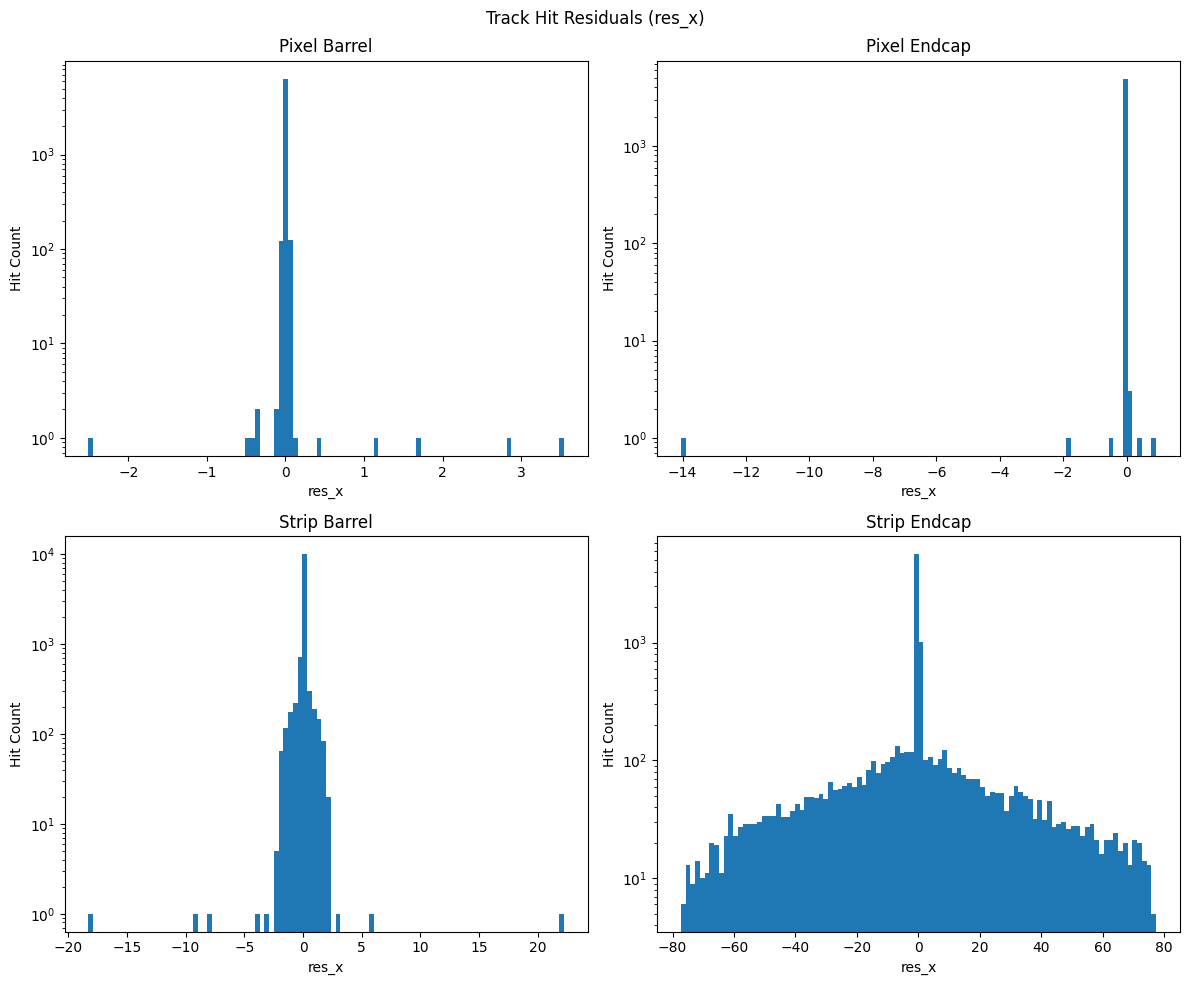

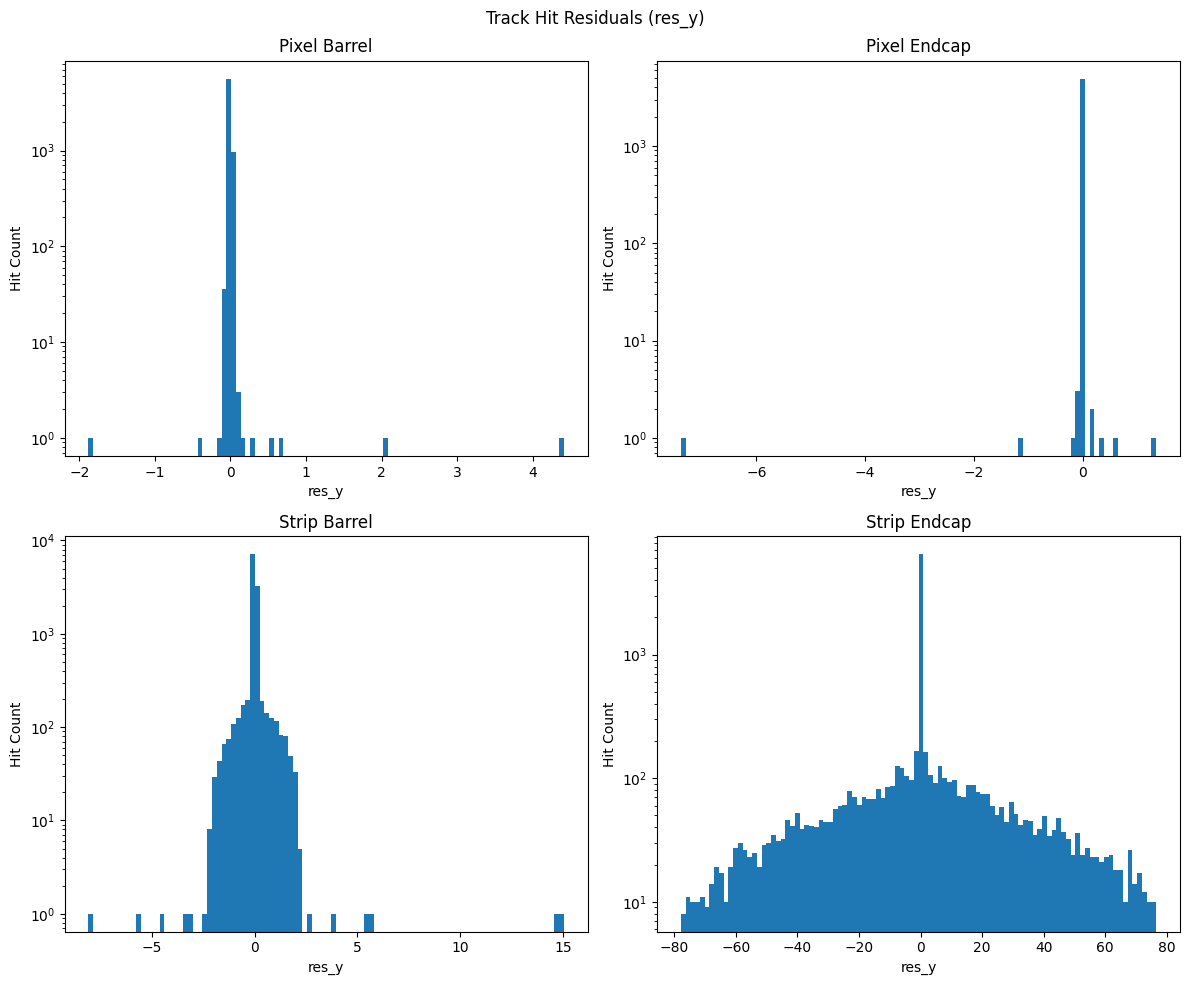

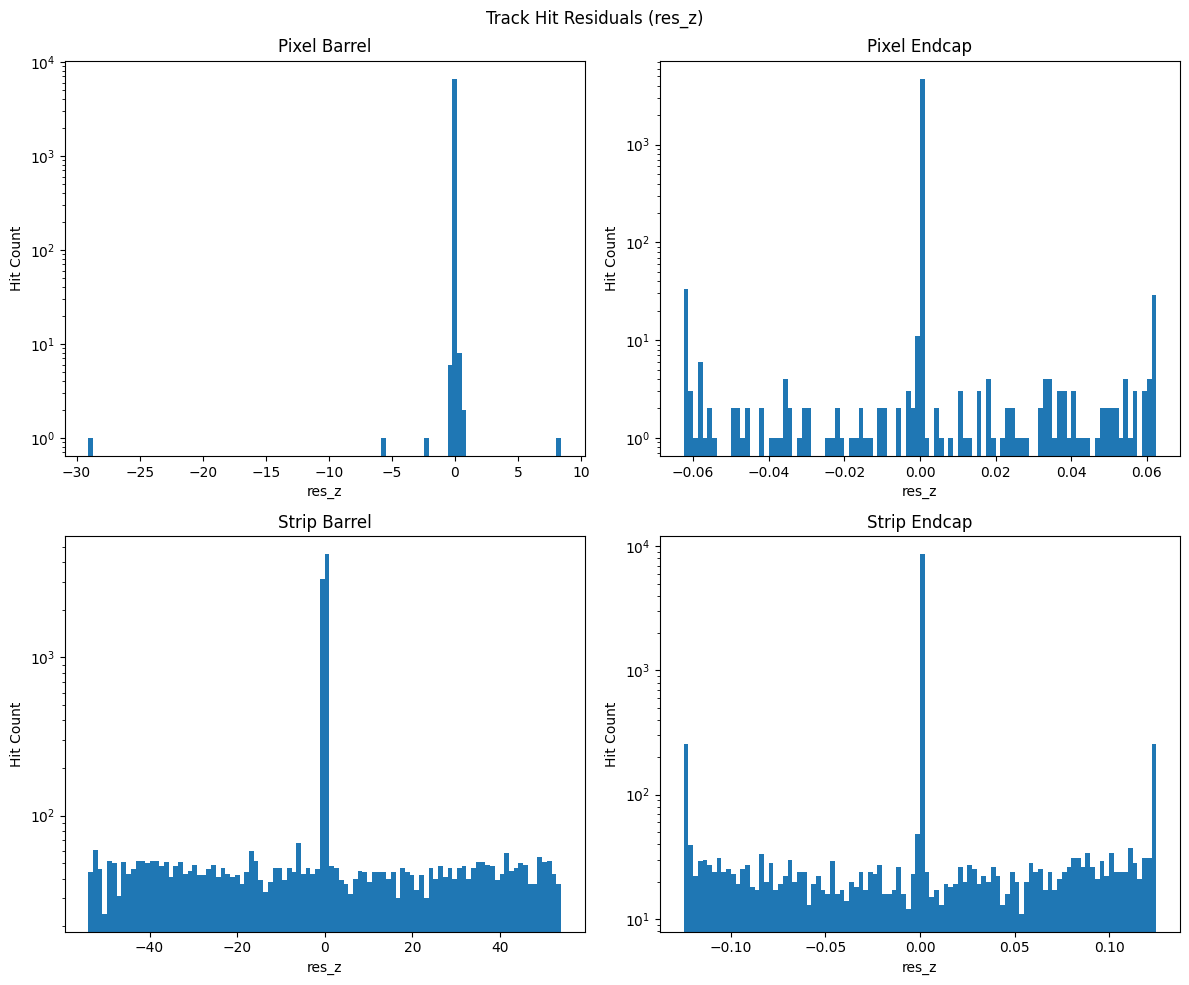

In [24]:
tracker_hits = gHd.get_tracker_hits()

tracker_hits['res_x'] = tracker_hits['true_x'] - tracker_hits['x']
tracker_hits['res_y'] = tracker_hits['true_y'] - tracker_hits['y']
tracker_hits['res_z'] = tracker_hits['true_z'] - tracker_hits['z']

PIXEL_VOLUMES = [16, 17, 18]
STRIP_VOLUMES = [23, 24, 25, 28, 29, 30]
ENDCAP_VOLUMES = [16, 18, 23, 25, 28, 30]
BARREL_VOLUMES = [17, 24, 29]

is_endcap = tracker_hits['volume_id'].isin(ENDCAP_VOLUMES)
is_barrel = tracker_hits['volume_id'].isin(BARREL_VOLUMES)

is_pixel = tracker_hits['volume_id'].isin(PIXEL_VOLUMES)
is_strip = tracker_hits['volume_id'].isin(STRIP_VOLUMES)

r = np.sqrt(tracker_hits['x']**2 + tracker_hits['y']**2)
theta = np.arctan2(r, tracker_hits['z'])
eta = -np.log(np.tan(theta / 2.0))
'''
ETA_CUT = 1.5
is_barrel = np.abs(eta) < ETA_CUT
is_endcap = np.abs(eta) >= ETA_CUT'''

df_pixel_barrel = tracker_hits[is_pixel & is_barrel]
df_pixel_endcap = tracker_hits[is_pixel & is_endcap]
df_strip_barrel = tracker_hits[is_strip & is_barrel]
df_strip_endcap = tracker_hits[is_strip & is_endcap]

for residuals in ['res_x','res_y','res_z']:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Track Hit Residuals ({residuals})')

    # Top left: Pixel Barrel
    axes[0, 0].hist(df_pixel_barrel[residuals], bins=100, log=True)
    axes[0, 0].set_title('Pixel Barrel')

    # Top right: Pixel Endcap
    axes[0, 1].hist(df_pixel_endcap[residuals], bins=100, log=True)
    axes[0, 1].set_title('Pixel Endcap')

    # Bottom left: Strip Barrel
    axes[1, 0].hist(df_strip_barrel[residuals], bins=100, log=True)
    axes[1, 0].set_title('Strip Barrel')

    # Bottom right: Strip Endcap
    axes[1, 1].hist(df_strip_endcap[residuals], bins=100, log=True)
    axes[1, 1].set_title('Strip Endcap')

    # Axis labels
    for ax in axes.flat:
        ax.set_xlabel(residuals)
        ax.set_ylabel('Hit Count')

    plt.tight_layout()
    plt.show()

# Repeat for res_y and res_z

In [25]:
import association_matrix as am

# --- 3. Main Test Function ---
if __name__ == "__main__":
    
    print("--- Test: Matrix Builder ---")
    
    # --- Load Data ---
    print("Loading data (Events 0-9)...")
    try:
        particles = gHd.get_particles()
        tracker_hits = gHd.get_tracker_hits()
        calo_hits = gHd.get_calo_hits()
    except Exception as e:
        print(f"\nERROR: Failed to load data using gHd functions.")
        print(f"Details: {e}")
        print("Please check your file paths in 'get_HEP_data.py'.")
        exit()
        
    print("Data loaded successfully.")

    # --- Run Function ---
    print("\nRunning create_sparse_matrices()...")
    trk_mat, calo_mat, p_list, p_map = am.sparse_association_matrix(
        particles, tracker_hits, calo_hits
    )
    print("Function completed.")

    # --- Test 1: Shape Check ---
    print("\n--- Test 1: Shape Check ---")
    expected_rows_trk = tracker_hits.index.max() + 1
    expected_rows_calo = calo_hits.index.max() + 1
    expected_cols = len(p_list)
    
    print(f"Particle List Size: {expected_cols}")
    print(f"Tracker Matrix Shape: {trk_mat.shape} (Rows, Cols)")
    print(f"  - Expected Shape: ({expected_rows_trk}, {expected_cols})")
    assert trk_mat.shape == (expected_rows_trk, expected_cols)
    
    print(f"Calo Matrix Shape:    {calo_mat.shape} (Rows, Cols)")
    print(f"  - Expected Shape: ({expected_rows_calo}, {expected_cols})")
    assert calo_mat.shape == (expected_rows_calo, expected_cols)
    print("  - PASSED: Shapes are correct.")

    # --- Test 2: Tracker Association ---
    print("\n--- Test 2: Tracker 1-to-1 Lookup ---")
    
    # Find all tracker hits that are guaranteed to be in our particle map
    valid_hits_mask = tracker_hits['particle_id'].isin(p_map.index)
    valid_test_hits = tracker_hits[valid_hits_mask]
    
    if valid_test_hits.empty:
        print("  - WARNING: No tracker hits match any particles in the list. Skipping test.")
    else:
        # Pick the 100th valid hit to test (or 0th if fewer than 100)
        test_hit_index = min(100, len(valid_test_hits) - 1)
        test_hit = valid_test_hits.iloc[test_hit_index]
        
        # .name gives us the original DataFrame index (our row number)
        test_hit_idx = test_hit.name 
        true_pid = test_hit['particle_id']
        
        # This is now guaranteed to work
        test_col_idx = p_map[true_pid]
        matrix_val = trk_mat[test_hit_idx, test_col_idx]
        
        print(f"Checking Tracker Hit (Index {test_hit_idx})...")
        print(f"  - True Particle ID: {true_pid}")
        print(f"  - Mapped to Column: {test_col_idx}")
        print(f"  - Value in matrix at ({test_hit_idx}, {test_col_idx}): {matrix_val}")
        assert matrix_val == 1
        print("  - PASSED: Matrix contains a 1.")

    # --- Test 3: Calo Sum Check (Your Request) ---
    print("\n--- Test 3: Calo 1-to-Many Sum ---")
    
    # Find a hit that appears multiple times (is multi-particle)
    calo_hit_counts = calo_hits.index.value_counts()
    multi_particle_hits = calo_hit_counts[calo_hit_counts > 1]
    
    if multi_particle_hits.empty:
        print("  - WARNING: No multi-particle calo hits found in this data. Skipping test.")
    else:
        # Pick the first hit that has multiple particles
        test_hit_idx_calo = multi_particle_hits.index[0]
        
        # Get the row from the matrix and sum it (this is the 82.0)
        matrix_particle_count = calo_mat.getrow(test_hit_idx_calo).sum()
        
        # --- Manually calculate the "true" valid count ---
        
        # 1. Get all contribution rows for this specific hit
        hit_contributions = calo_hits.loc[test_hit_idx_calo]
        
        # 2. Get the particle IDs from those rows
        # (Handle case if loc returns a single row)
        if isinstance(hit_contributions, pd.Series):
             pids_for_hit = pd.Series([hit_contributions['contrib_particle_ids']])
        else:
             pids_for_hit = hit_contributions['contrib_particle_ids']
             
        # 3. Check which of these PIDs are in our particle map
        valid_pids_mask = pids_for_hit.isin(p_map.index)
        
        # 4. Count how many are valid
        true_valid_particle_count = valid_pids_mask.sum()
        
        # --- End manual calculation ---
        
        print(f"Checking Calo Hit (Index {test_hit_idx_calo})...")
        print(f"  - Total Contributions (from pandas):   {len(pids_for_hit)}")
        print(f"  - Valid Contributions (in p_map):     {true_valid_particle_count}")
        print(f"  - Matrix Particle Count (from sum):   {matrix_particle_count}")
        
        # This will now assert 82 == 82.0
        assert true_valid_particle_count == matrix_particle_count
        print("  - PASSED: Matrix sum matches valid contribution count.")

    print("\n--- ALL TESTS PASSED ---")

--- Test: Matrix Builder ---
Loading data (Events 0-9)...
Data loaded successfully.

Running create_sparse_matrices()...
Function completed.

--- Test 1: Shape Check ---
Particle List Size: 2203
Tracker Matrix Shape: (34950, 2203) (Rows, Cols)
  - Expected Shape: (34950, 2203)
Calo Matrix Shape:    (211158, 2203) (Rows, Cols)
  - Expected Shape: (211158, 2203)
  - PASSED: Shapes are correct.

--- Test 2: Tracker 1-to-1 Lookup ---
Checking Tracker Hit (Index 102)...
  - True Particle ID: 358.0
  - Mapped to Column: 313
  - Value in matrix at (102, 313): 1.0
  - PASSED: Matrix contains a 1.

--- Test 3: Calo 1-to-Many Sum ---
Checking Calo Hit (Index 174738)...
  - Total Contributions (from pandas):   582
  - Valid Contributions (in p_map):     82
  - Matrix Particle Count (from sum):   82.0
  - PASSED: Matrix sum matches valid contribution count.

--- ALL TESTS PASSED ---
